# **Daily Seasonal Adjustment (DSA)**
Antes de ejecutar, **es importante completar/modificar todas las secciones marcadas con [TBC]**:
* (2) Lectura de datos > Subida manual de CSV: ruta del fichero de entrada (`INPUT_PATH`).
* (3) Procesamiento del dato > Dummies (ad-hoc).
* (4) Modelización > Hiperparámetros DSA (`TARGET_COL`, `FORECAST_HORIZON`, etc.).
* (5) Guardado: ruta del fichero de salida (`OUTPUT_PATH`).

## (1) Instalación y lectura de paquetes

In [ ]:
system("apt-get update -qq")
system("apt-get install -y default-jdk r-cran-rjava")

system("R CMD javareconf")

install.packages(c(
  "dsa",
  "xts",
  "zoo",
  "lubridate",
  "dplyr",
  "openxlsx",
  "timeDate",
  "ggplot2",
  "reshape2",
  "reticulate"   # puente R <-> Python para la conexión a Google Sheets (sección 2)
), repos = "https://cloud.r-project.org")

In [2]:
rm(list = ls())
Sys.setenv(TZ = "Europe/Madrid")

library(dplyr)
library(xts)
library(lubridate)
library(dsa)
library(openxlsx)
library(timeDate)
library(ggplot2)
library(timeDate) # Para la función Easter()


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from 

## (2) Lectura del dato [**TBC**]

### Subida manual de CSV [**TBC**]

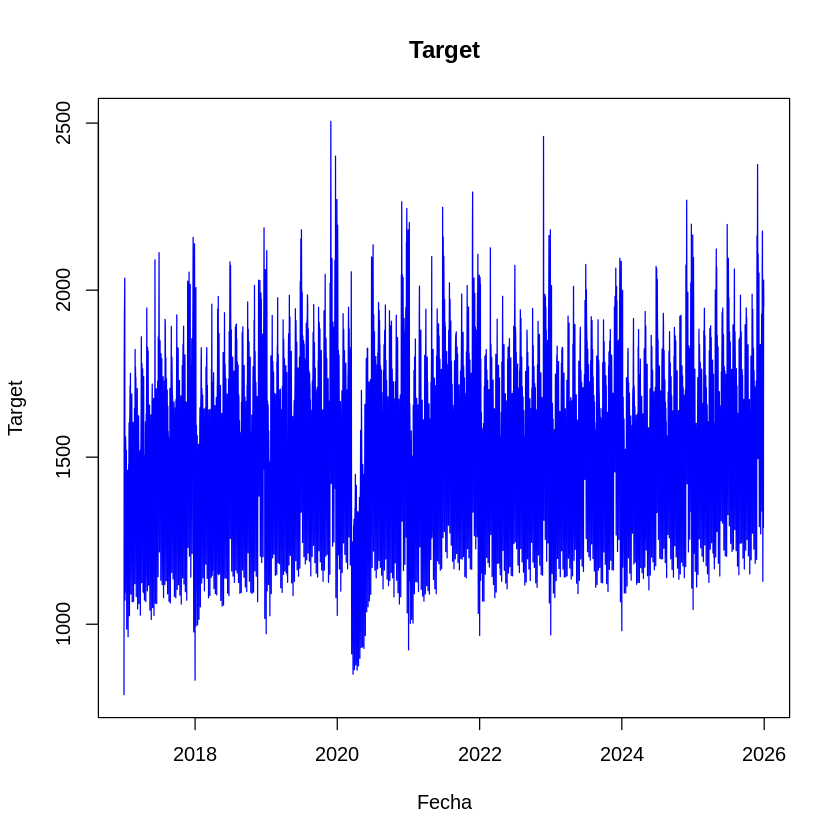

In [4]:
# ============================================================
# Manual
# ============================================================
# Definir la ruta
INPUT_PATH <- "Data - Consumo_BD.csv"

# Leer el archivo
Data <- read.csv(
  INPUT_PATH,
  skip = 2,
  header = TRUE,
  dec = ",",
  stringsAsFactors = FALSE
)

# Parsear las columnas
Data$timestamp <- as.Date(Data$timestamp, format = "%d/%m/%Y")
Data$target <- as.numeric(Data$target)
Data <- Data[, c("timestamp", "target")]

# Crear un pequeño plot de la evolución del target
plot(Data$timestamp, Data$target,
     type = "l",
     col = "blue",
     main = "Target",
     xlab = "Fecha",
     ylab = "Target")

### Conexión a Google Sheets (vía Python / `reticulate`)

In [ ]:
# ============================================================
# Conexión a Google Sheets reutilizando el flujo de Python (reticulate)
# ------------------------------------------------------------
# El runtime de R en Colab no puede autenticarse con gspread directamente
# (permisos), pero sí podemos ejecutar, a través de reticulate, el mismo
# script de Python que SÍ funciona en la corporación. Ejecutar SÓLO en Colab.
# ============================================================
library(reticulate)

# Identificadores de la hoja
FILE_ID <- "1hakzOf9fUA8dA9TLxeph4wrd3EpWUWS0jI8QbzfGBsg"
SHEET   <- "Consumo_BD"

# Flujo de autenticación + lectura en Python (idéntico al script corporativo)
reticulate::py_run_string('
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# Google Drive authentication
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

def read_GS(data_id, sheet):
    # Retrieve worksheet
    spreadsheet = gc.open_by_key(data_id)
    worksheet = spreadsheet.worksheet(sheet)

    # Read rows and convert to df
    rows = worksheet.get_all_values()
    df = pd.DataFrame.from_records(rows[1:], columns=rows[0])
    return df
')

# Traer la hoja a R como data.frame y parsear igual que en la subida manual
Data <- py$read_GS(FILE_ID, SHEET)
Data$timestamp <- as.Date(Data$timestamp, format = "%d/%m/%Y")
Data$target    <- as.numeric(gsub(",", ".", Data$target))   # decimal con coma -> punto
Data <- Data[, c("timestamp", "target")]

plot(Data$timestamp, Data$target, type = "l", col = "blue",
     main = "Target (Google Sheets)", xlab = "Fecha", ylab = "Target")

## (3) Procesamiento del dato [**TBC**]

### Semana (5 o 7 días)
Elija el calendario en `SERIES_WEEK_DAYS`: **7** = calendario completo, **5** = calendario de negocio (lunes-viernes). La elección se propaga al experimento principal (sección 4.B).

In [ ]:
# ============================================================
# Calendario de la serie: completo (7) o de negocio (5)
# ============================================================

### TBC: 7 = calendario completo (lun-dom); 5 = calendario de negocio (lun-vie)
SERIES_WEEK_DAYS <- 7

# Filtra un data.frame al calendario elegido (se usa internamente en el
# experimento de la sección 4.B). NOTA: NO filtramos `Data` aquí: la serie
# original se mantiene completa (los fines de semana son datos reales) para que
# la ruta robusta de negocio pueda ajustar el DSA sobre 7 días y evaluar sólo
# los días hábiles. El filtrado se aplica dentro de run_growing_daily_forecast().
keep_calendar_days <- function(df, date_col = "timestamp", week_days = SERIES_WEEK_DAYS) {
  df[[date_col]] <- as.Date(df[[date_col]])
  if (week_days == 5) {
    df <- df[as.integer(format(df[[date_col]], "%u")) <= 5, , drop = FALSE]
  } else if (week_days != 7) {
    stop("week_days debe ser 5 (lunes-viernes) o 7 (calendario completo).")
  }
  df
}

Data[["timestamp"]] <- as.Date(Data[["timestamp"]])

### Transformación (nivel o log o log1p) [**TBC**]

In [6]:
# ============================================================
# Transformation
# ============================================================

### TBC: Choose between "level" / "log" / "log1p"
TRANSFORMATION <- "log"

# Funciones de transformación y reversión
transform_level <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(log(x))
  }

  if (transformation == "log1p") {
    return(log1p(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

inverse_transform <- function(x, transformation = c("log", "log1p", "level")) {
  transformation <- match.arg(transformation)

  if (transformation == "log") {
    return(exp(x))
  }

  if (transformation == "log1p") {
    return(expm1(x))
  }

  if (transformation == "level") {
    return(x)
  }
}

# Aplicar transformación
Data$target_proc <- transform_level(Data$target, TRANSFORMATION)

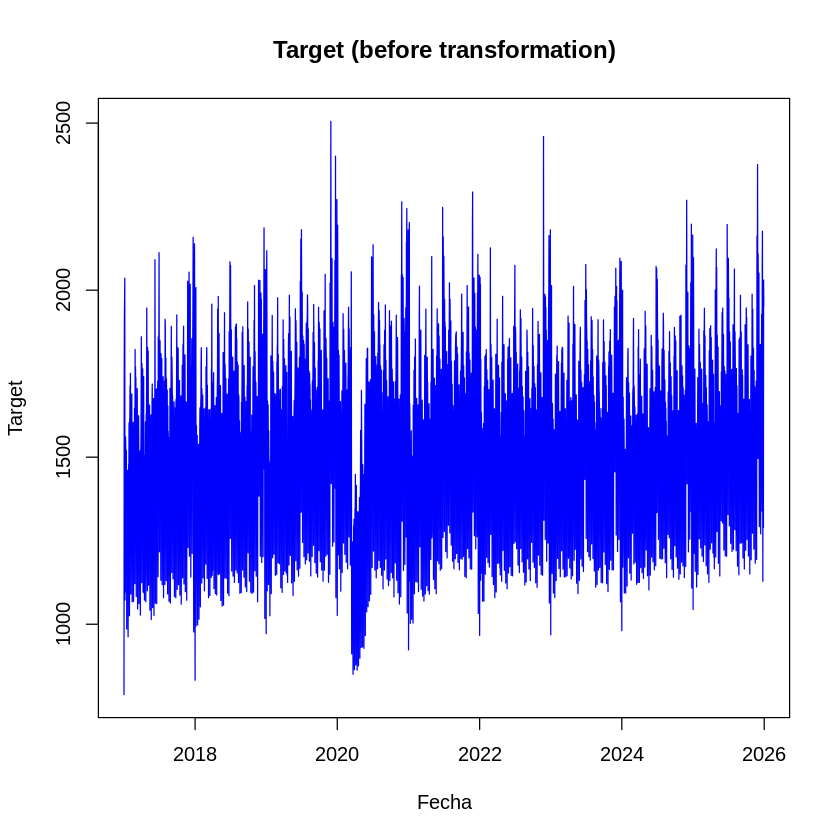

In [7]:
# Plot original series
plot(Data$timestamp, Data$target,
     type = "l",
     col = "blue",
     main = "Target (before transformation)",
     xlab = "Fecha",
     ylab = "Target")

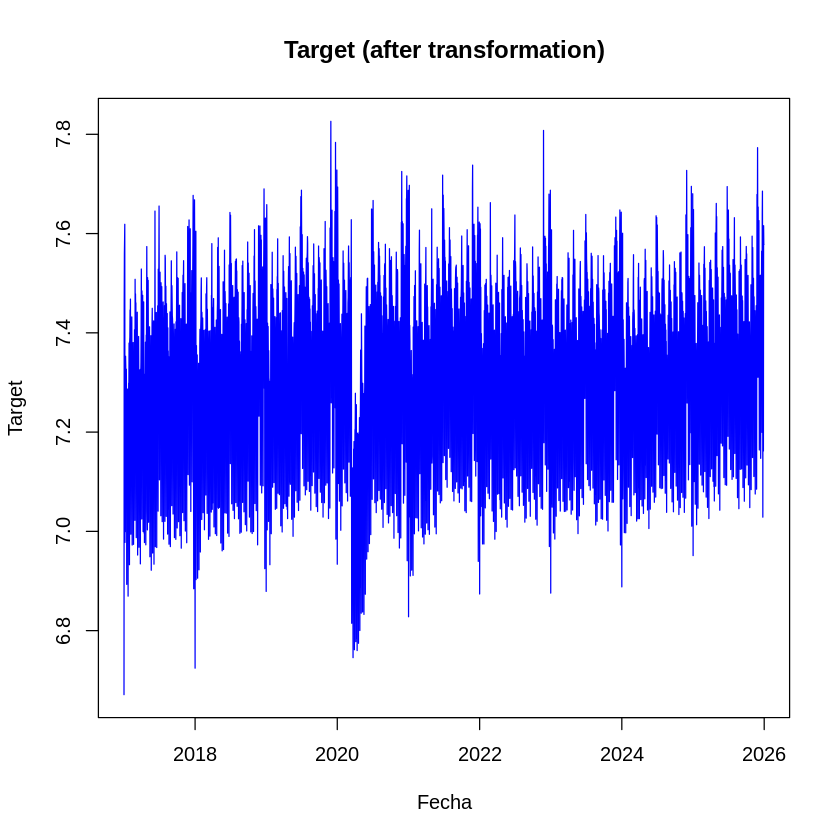

In [8]:
# Plot resulting series
Data$target_proc <- as.numeric(Data$target_proc)
plot(Data$timestamp, Data$target_proc,
     type = "l",
     col = "blue",
     main = "Target (after transformation)",
     xlab = "Fecha",
     ylab = "Target")

### Dummies [**TBC**]

In [9]:
# ============================================================
# Calendar covariates y calendario de la serie
# ============================================================

add_calendar_covariates <- function(df, date_col = "timestamp") {
  df <- df %>%
    mutate(
      timestamp = as.Date(.data[[date_col]]),
      dow = wday(timestamp, week_start = 1) - 1,
      month = month(timestamp),
      day = day(timestamp),
      week = isoweek(timestamp),
      is_weekend = as.integer(dow >= 5)
    )

  years <- unique(year(df$timestamp))

  fixed_holidays <- do.call(c, lapply(years, function(y) {
    as.Date(c(
      paste0(y, "-01-01"), paste0(y, "-01-06"), paste0(y, "-05-01"),
      paste0(y, "-05-02"), paste0(y, "-06-24"), paste0(y, "-08-15"),
      paste0(y, "-10-12"), paste0(y, "-11-01"), paste0(y, "-12-06"),
      paste0(y, "-12-08"), paste0(y, "-12-25"), paste0(y, "-12-31")
    ))
  }))

  easter_sundays <- as.Date(Easter(years))
  easter_related <- do.call(c, lapply(easter_sundays, function(e) {
    as.Date(e + days(-7:1))
  }))

  holidays_all <- unique(c(fixed_holidays, easter_related))

  df <- df %>%
    mutate(
      is_holiday = as.integer(timestamp %in% holidays_all),
      is_pre_holiday = as.integer((timestamp + days(1)) %in% holidays_all),
      is_post_holiday = as.integer((timestamp - days(1)) %in% holidays_all),
      is_bridge_day = as.integer(
        (is_weekend == 0 & is_holiday == 0) & (is_pre_holiday == 1 | is_post_holiday == 1)
      ),
      is_easter_week = as.integer(timestamp %in% easter_related)
    )

  return(df)
}

# Añadir covariates
Data <- add_calendar_covariates(Data, "timestamp")
head(Data)

,timestamp,target,target_proc,dow,month,day,week,is_weekend,is_holiday,is_pre_holiday,is_post_holiday,is_bridge_day,is_easter_week
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>
1,2017-01-01,789.172,6.670984,6,1,1,52,1,1,0,0,0,0
2,2017-01-02,1731.510,7.456749,0,1,2,1,0,0,0,1,1,0
3,2017-01-03,1919.130,7.559627,1,1,3,1,0,0,0,0,0,0
4,2017-01-04,1972.950,7.587285,2,1,4,1,0,0,0,0,0,0
5,2017-01-05,2035.940,7.618713,3,1,5,1,0,0,1,0,1,0
6,2017-01-06,1072.560,6.977804,4,1,6,1,0,1,0,0,0,0


In [10]:
safe_log_scalar <- function(x) {
  if (length(x) == 0 || is.na(x) || !is.finite(x) || x <= 0) {
    return(NA_real_)
  }
  log(x)
}

aggregate_level <- function(x, agg = "sum", empty_value = NA_real_) {
  x <- as.numeric(x)
  x <- x[is.finite(x)]

  if (length(x) == 0) {
    return(empty_value)
  }

  if (agg == "sum") {
    return(sum(x))
  }

  if (agg == "mean") {
    return(mean(x))
  }

  stop("agg debe ser 'sum' o 'mean'.")
}

### Conversión a serie temporal

In [11]:
# ============================================================
# Convert to xts
# ============================================================
Data <- Data %>% arrange(timestamp)
Data_ts <- xts(x = Data[, -1], order.by = Data$timestamp)
Data_ts <- na.omit(Data_ts)
Data <- na.omit(Data)

## (4) DSA [**TBC**]

Some hyperarameters...
* `model`: Allows specifying the ARIMA order (e.g., \(c(3,1,0)\)) for the non-seasonal part.
* `fourier_number`: Determines the number of trigonometric regressors used to model annual and monthly seasonality.
* `s.window`: Specifies the STL parameter for seasonality smoothing, allowing the seasonal pattern to change over time.
* `outlier`: Whether the algorithm includes automatic outlier adjustment or not.

See the full hyperparam documentation [here](https://danielollech.r-universe.dev/dsa/doc/manual.html).

### (4.A) Predicción univariable **estática**

In [ ]:
TARGET_COLUMN <- "target_proc"
FORECAST_HORIZON <- 30

  |======================================================================| 100%
         MAE       RMSE      MAPE     sMAPE        R2
1 0.06795459 0.07949971 0.9192042 0.9186001 0.7712174


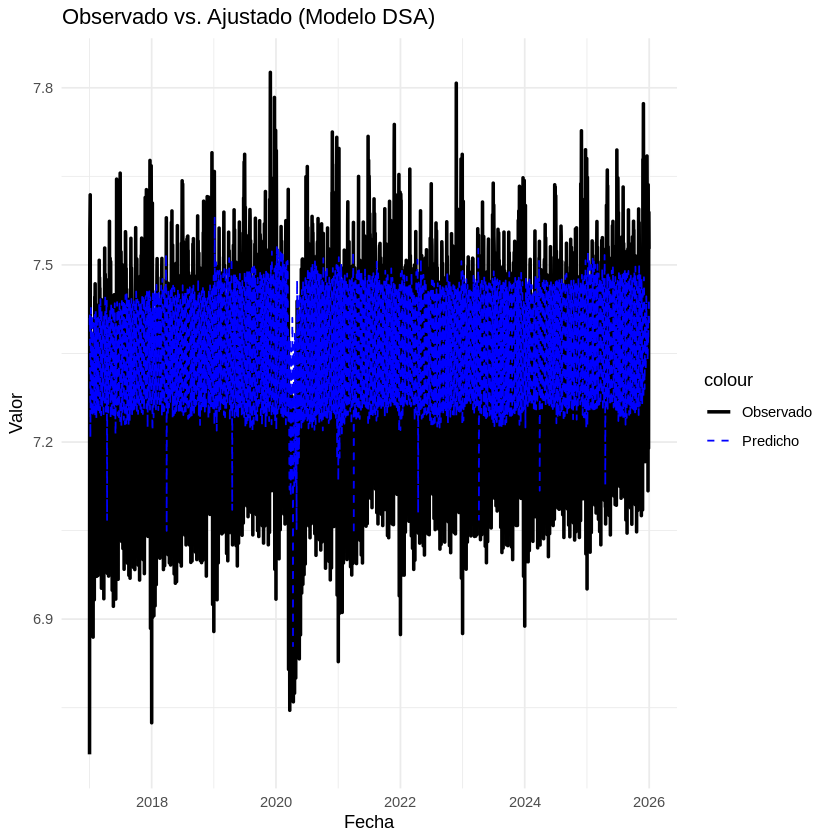

In [ ]:
# ============================================================
# DSA Model - Dentro de Muestra
# ============================================================
calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

regressors <- index(Data_ts)[1:(nrow(Data_ts) - FORECAST_HORIZON)]
regressors_future <- index(Data_ts)[(nrow(Data_ts) - FORECAST_HORIZON + 1):nrow(Data_ts)]

model_list <- list()
results_list <- list()

reg <- multi_xts2ts(
  Data_ts[regressors, calendar_regressors],
  short = TRUE
)

regf <- multi_xts2ts(
  Data_ts[regressors_future, calendar_regressors],
  short = TRUE
)

model_list[[TARGET_COLUMN]] <- dsa(
  Data_ts[regressors, TARGET_COLUMN],
  regressor = reg,
  forecast_regressor = regf,
  h = FORECAST_HORIZON,
  automodel = 'full',
  ic = 'bic',
  include.constant = TRUE
)

results_list[[TARGET_COLUMN]] <- data.frame(
  date = index(model_list[[TARGET_COLUMN]]$output$original),
  original = as.numeric(model_list[[TARGET_COLUMN]]$output$original),
  seas_adj = as.numeric(model_list[[TARGET_COLUMN]]$output$seas_adj),
  trend = as.numeric(model_list[[TARGET_COLUMN]]$output$trend),
  sc_fac = as.numeric(model_list[[TARGET_COLUMN]]$output$sc_fac)
)

# Función para métricas
calculate_metrics <- function(actual, predicted) {
  mae  <- mean(abs(actual - predicted), na.rm = TRUE)
  rmse <- sqrt(mean((actual - predicted)^2, na.rm = TRUE))
  mape <- mean(abs((actual - predicted) / actual), na.rm = TRUE) * 100
  smape <- mean(2 * abs(actual - predicted) / (abs(actual) + abs(predicted)), na.rm = TRUE) * 100
  rss <- sum((actual - predicted)^2, na.rm = TRUE)
  tss <- sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
  r2  <- 1 - (rss / tss)
  return(data.frame(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, R2=r2))
}

# Extraer datos
res <- results_list[[TARGET_COLUMN]]
actual_vals <- as.numeric(res$original)
pred_vals <- as.numeric(res$trend) + as.numeric(res$sc_fac) # Tendencia + Factores Estacionales y de Calendario
metrics <- calculate_metrics(actual_vals, pred_vals)
print(metrics)

# Plot
ggplot(res, aes(x = date)) +
  geom_line(aes(y = original, color = "Observado"), linewidth = 1) +
  geom_line(aes(y = seas_adj, color = "Predicho"), linetype = "dashed") +
  labs(title = "Observado vs. Ajustado (Modelo DSA)", y = "Valor", x = "Fecha") +
  theme_minimal() +
  scale_color_manual(values = c("Observado" = "black", "Predicho" = "blue"))

  |======================================================================| 100%
[1] "--- MÉTRICAS DE FORECAST EN EL PERIODO TEST (FUTURO) ---"
         MAE       RMSE     MAPE     sMAPE        R2
1 0.05833455 0.07202522 0.780373 0.7791907 0.8029672


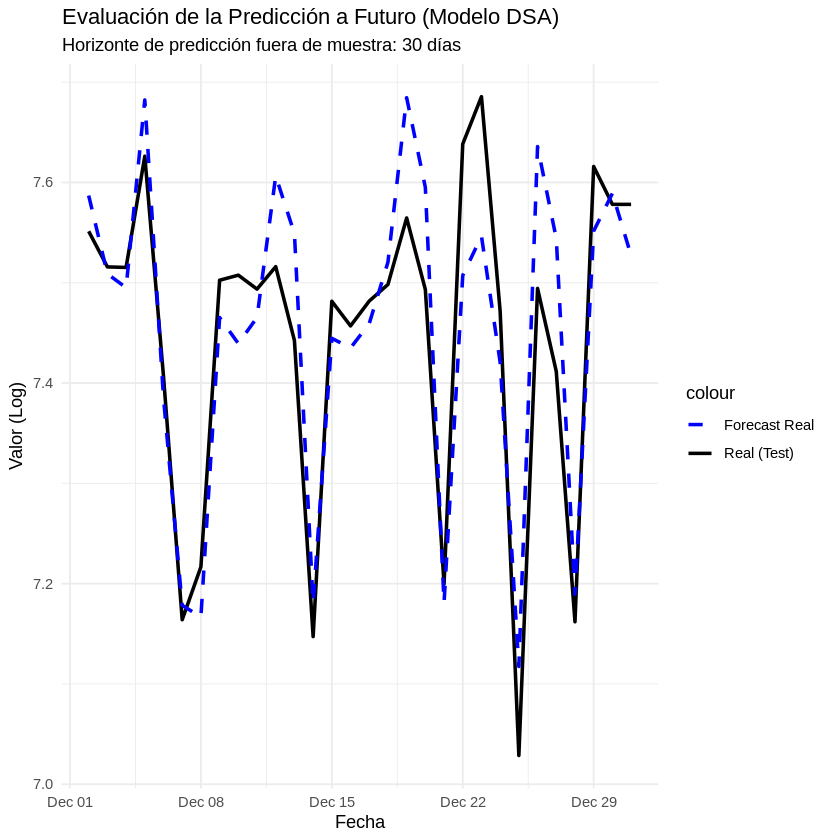

In [ ]:
# ============================================================
# DSA Model - Fuera de Muestra
# ============================================================
calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

# Separación de índices temporales (Train vs Test)
regressors <- index(Data_ts)[1:(nrow(Data_ts) - FORECAST_HORIZON)]
regressors_future <- index(Data_ts)[(nrow(Data_ts) - FORECAST_HORIZON + 1):nrow(Data_ts)]

model_list <- list()

reg <- multi_xts2ts(
  Data_ts[regressors, calendar_regressors, drop = FALSE],
  short = TRUE
)

regf <- multi_xts2ts(
  Data_ts[regressors_future, calendar_regressors, drop = FALSE],
  short = TRUE
)

# Entrenamos solo con el periodo de regresores (Train)
model_list[[TARGET_COLUMN]] <- dsa(
  Data_ts[regressors, TARGET_COLUMN],
  regressor = reg,
  forecast_regressor = regf,
  h = FORECAST_HORIZON,
  automodel = 'full',
  ic = 'bic',
  include.constant = TRUE
)

# ============================================================
# EXTRACCIÓN DEL PERIOD TEST (FUTURO)
# ============================================================

# 1. Extraemos la serie proyectada completa (Pasado + Horizonte Futuro)
full_series_forecast <- get_original(model_list[[TARGET_COLUMN]], forecast = TRUE)

# 2. Cortamos estrictamente los últimos 'FORECAST_HORIZON' días para el Test
pred_vals   <- as.numeric(tail(full_series_forecast, FORECAST_HORIZON))
actual_vals <- as.numeric(Data_ts[regressors_future, TARGET_COLUMN])

# 3. Creamos un dataframe limpio exclusivo para el gráfico y control del Test
res_test <- data.frame(
  date     = regressors_future,
  real     = actual_vals,
  forecast = pred_vals
)

# ============================================================
# Cálculo de Métricas (Ajuste a Futuro Real)
# ============================================================
calculate_metrics <- function(actual, predicted) {
  mae  <- mean(abs(actual - predicted), na.rm = TRUE)
  rmse <- sqrt(mean((actual - predicted)^2, na.rm = TRUE))
  mape <- mean(abs((actual - predicted) / actual), na.rm = TRUE) * 100
  smape <- mean(2 * abs(actual - predicted) / (abs(actual) + abs(predicted)), na.rm = TRUE) * 100
  rss <- sum((actual - predicted)^2, na.rm = TRUE)
  tss <- sum((actual - mean(actual, na.rm = TRUE))^2, na.rm = TRUE)
  r2  <- 1 - (rss / tss)
  return(data.frame(MAE=mae, RMSE=rmse, MAPE=mape, sMAPE=smape, R2=r2))
}

metrics <- calculate_metrics(res_test$real, res_test$forecast)
print("--- MÉTRICAS DE FORECAST EN EL PERIODO TEST (FUTURO) ---")
print(metrics)

# ============================================================
# Gráfico del Periodo de Forecast (Test)
# ============================================================
ggplot(res_test, aes(x = date)) +
  geom_line(aes(y = real, color = "Real (Test)"), linewidth = 1) +
  geom_line(aes(y = forecast, color = "Forecast Real"), linetype = "dashed", linewidth = 1) +
  labs(
    title = "Evaluación de la Predicción a Futuro (Modelo DSA)",
    subtitle = paste("Horizonte de predicción fuera de muestra:", FORECAST_HORIZON, "días"),
    y = "Valor",
    x = "Fecha"
  ) +
  theme_minimal() +
  scale_color_manual(values = c("Real (Test)" = "black", "Forecast Real" = "blue"))

### (4.B) Predicción univariable **en vendimias** [**TBC**]

#### Prueba básica

In [ ]:
# Configuración
TARGET_COLUMN <- "target_proc"
FORECAST_HORIZON <- 90
SKIP_STEPS <- 30 # Cada cuántos días hacemos un nuevo corte
WINDOWS <- 3 # Cuántas vendimias queremos probar

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
[1] "--- MÉTRICAS EN DIARIO (LOGS) ---"
         MAE       RMSE      MAPE     sMAPE        R2   window
1 0.02940866 0.03872376 0.3993136 0.3989318 0.9231979 Window 1
2 0.03150061 0.04559224 0.4302772 0.4311847 0.8881201 Window 2
3 0.03676550 0.04760517 0.4986943 0.4984833 0.8932598 Window 3
4 0.04725943 0.06016918 0.6379638 0.6366455 0.8523103 Window 4
5 0.03623355 0.04802259 0.4915622 0.4913113 0.8892220     Mean


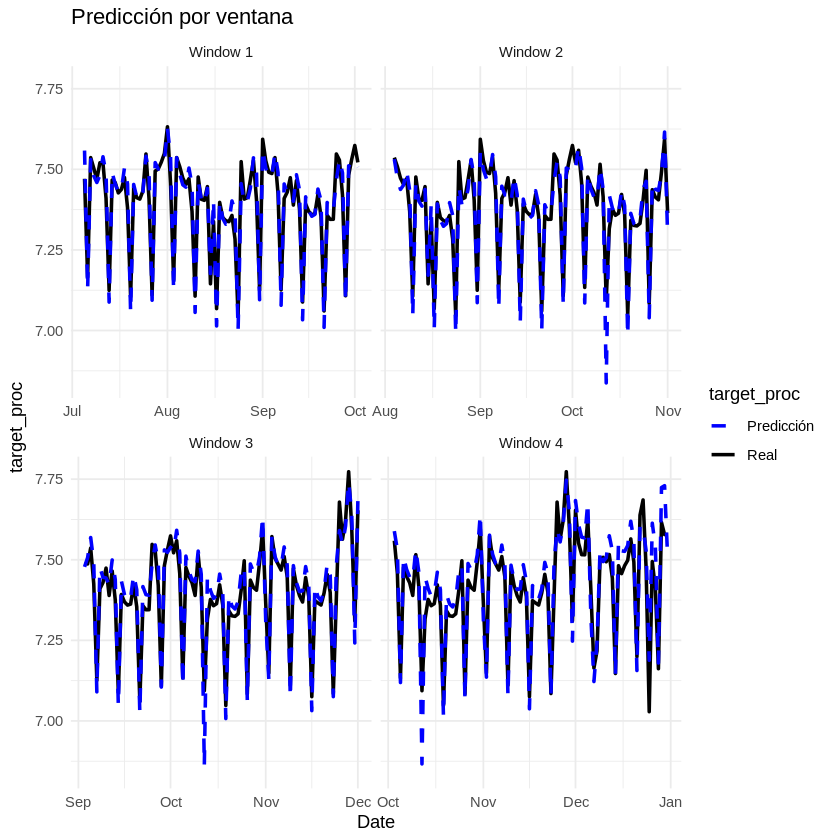

In [ ]:
# ============================================================
# Estimación Diaria
# (Predicción en logs > Métricas en logs)
# ============================================================

calendar_regressors <- setdiff(colnames(Data_ts), TARGET_COLUMN)

windows <- seq(
  nrow(Data_ts) - (WINDOWS * SKIP_STEPS) - FORECAST_HORIZON,
  nrow(Data_ts) - FORECAST_HORIZON,
  by = SKIP_STEPS
)

window_results <- list()
window_metrics <- data.frame()

for (i in seq_along(windows)) {

  skip_idx <- windows[i]

  full_train <- Data_ts[1:skip_idx, ]
  full_test  <- Data_ts[(skip_idx + 1):(skip_idx + FORECAST_HORIZON), ]

  y_train <- full_train[, TARGET_COLUMN]
  y_test  <- full_test[, TARGET_COLUMN]

  reg_train_xts <- full_train[, calendar_regressors]
  reg_test_xts  <- full_test[, calendar_regressors]

  reg_train <- multi_xts2ts(cbind(reg_train_xts))
  reg_test  <- multi_xts2ts(cbind(reg_test_xts), short = TRUE)

  valid_cols <- apply(reg_train, 2, var) > 0
  reg_train <- reg_train[, valid_cols]
  reg_test  <- reg_test[, valid_cols]

  fit <- dsa(
    y_train,
    regressor = reg_train,
    forecast_regressor = reg_test,
    h = FORECAST_HORIZON,
    automodel = 'reduced',
    ic = 'bic',
    include.constant = TRUE
  )

  # Extraemos la serie proyectada completa
  full_forecast <- get_original(fit, forecast = TRUE)

  # Extraemos únicamente los pasos futuros correspondientes al forecast real
  pred <- as.numeric(tail(full_forecast, FORECAST_HORIZON))
  real <- as.numeric(y_test)

  window_results[[i]] <- data.frame(
    fecha = index(y_test),
    pred = pred,
    real = real,
    window = paste("Window", i)
  )

  m <- calculate_metrics(real, pred)
  m$window = paste("Window", i)
  window_metrics <- rbind(window_metrics, m)
}

# Tabla de métricas
met_num <- window_metrics[, sapply(window_metrics, is.numeric), drop = FALSE]
promedios <- colMeans(met_num, na.rm = TRUE)
mean_row <- as.data.frame(t(promedios))
mean_row$window <- "Mean"
window_metrics <- rbind(window_metrics, mean_row)
print("--- MÉTRICAS EN DIARIO (LOGS) ---")
print(window_metrics)

# Gráfico
df_plot <- do.call(rbind, window_results)
ggplot(df_plot, aes(x = fecha)) +
  geom_line(aes(y = real, color = "Real"), linewidth = 1) +
  geom_line(aes(y = pred, color = "Predicción"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") + # Modificado a free_x para mantener escalas verticales comparables si se desea
  theme_minimal() +
  labs(title = "Predicción por ventana", color = TARGET_COLUMN, y = TARGET_COLUMN, x = "Date") +
  scale_color_manual(values = c("Real" = "black", "Predicción" = "blue"))

[1] "--- MÉTRICAS EN AGREGACIÓN SEMANAL (LOGS) ---"
          MAE        RMSE       MAPE      sMAPE        R2        window
1 0.009772375 0.012839416 0.10979532 0.10971336 0.9986780      Window 1
2 0.007245930 0.009693512 0.07757505 0.07760382 0.9695526      Window 2
3 0.019704601 0.021595680 0.21645919 0.21618433 0.9976120      Window 3
4 0.030231096 0.034312857 0.32982490 0.32911655 0.9849758      Window 4
5 0.016738500 0.019610366 0.18341362 0.18315452 0.9877046 Mean (Weekly)


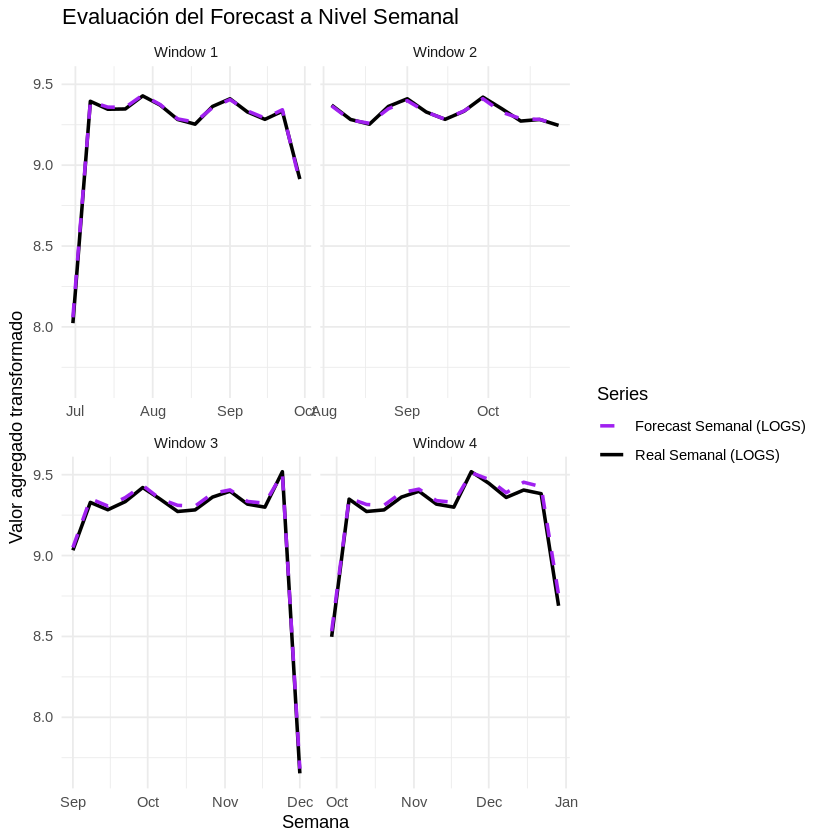

In [ ]:
# ============================================================
# Estimación Semanal
# (Tomar predicción diaria en logs > Convertir a niveles > Agregar en Semanas > Transformar a logs > Métricas en logs)
# ============================================================

# Revertimos los resultados diarios a NIVELES
df_daily_results <- do.call(rbind, window_results) %>%
  mutate(
    fecha = as.Date(fecha),
    # Volver de escala procesada diaria a niveles diarios
    real_level = inverse_transform(real, TRANSFORMATION),
    pred_level = inverse_transform(pred, TRANSFORMATION)
  )

# Agregación semanal en NIVELES y posterior transformación semanal a LOGS
df_weekly_metrics <- df_daily_results %>%
  mutate(
    semana = floor_date(fecha, unit = "week", week_start = 1)
  ) %>%
  group_by(window, semana) %>%
  summarise(
    real_weekly_level = sum(real_level, na.rm = TRUE),
    pred_weekly_level = sum(pred_level, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    # Transformación de vuelta a LOGS
    real_weekly_proc = transform_level(real_weekly_level, TRANSFORMATION),
    pred_weekly_proc = transform_level(pred_weekly_level, TRANSFORMATION)
  )
weekly_metrics_table <- data.frame()
for (w in unique(df_weekly_metrics$window)) {
  sub_df <- filter(df_weekly_metrics, window == w)
  m_weekly <- calculate_metrics(
    sub_df$real_weekly_proc,
    sub_df$pred_weekly_proc
  )
  m_weekly$window <- w
  weekly_metrics_table <- rbind(weekly_metrics_table, m_weekly)
}
met_num_w <- weekly_metrics_table[, sapply(weekly_metrics_table, is.numeric), drop = FALSE]
mean_row_w <- as.data.frame(t(colMeans(met_num_w, na.rm = TRUE)))
mean_row_w$window <- "Mean (Weekly)"
weekly_metrics_table <- rbind(weekly_metrics_table, mean_row_w)

print("--- MÉTRICAS EN AGREGACIÓN SEMANAL (LOGS) ---")
print(weekly_metrics_table)

# Gráfico semanal
ggplot(df_weekly_metrics, aes(x = semana)) +
  geom_line(aes(y = real_weekly_proc, color = "Real Semanal (LOGS)"), linewidth = 1) +
  geom_line(aes(y = pred_weekly_proc, color = "Forecast Semanal (LOGS)"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Evaluación del Forecast a Nivel Semanal",
    color = "Series",
    y = "Valor agregado transformado",
    x = "Semana"
  ) +
  scale_color_manual(
    values = c(
      "Real Semanal (LOGS)" = "black",
      "Forecast Semanal (LOGS)" = "purple"
    )
  )

[1] "--- MÉTRICAS EN AGREGACIÓN MENSUAL (LOGS) ---"
          MAE        RMSE       MAPE      sMAPE          R2         window
1 0.004268343 0.004274795 0.03949100 0.03948318   0.2237303       Window 1
2 0.001668136 0.002075503 0.01543665 0.01543849   0.9689842       Window 2
3 0.014151589 0.016464624 0.13069684 0.13058134 -48.4543617       Window 3
4 0.025267821 0.029095666 0.23210569 0.23174982   0.3065577       Window 4
5 0.011338972 0.012977647 0.10443255 0.10431321 -11.7387724 Mean (Monthly)


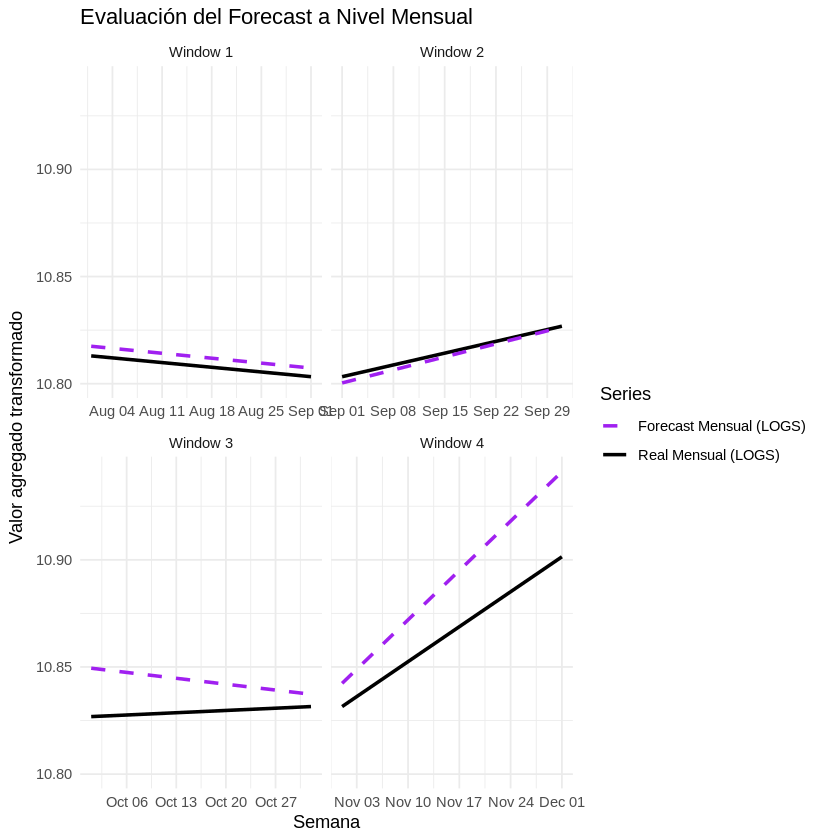

In [ ]:
# ============================================================
# Estimación mensual
# (Tomar predicción diaria en logs > Convertir a niveles > Agregar en Meses > Transformar a logs > Métricas en logs)
# ============================================================

df_monthly_metrics <- df_daily_results %>%
  mutate(
    mes = floor_date(fecha, unit = "month"),
    month_end = ceiling_date(mes, unit = "month") - days(1)  # Filtramos los meses incompletos
  ) %>%
  group_by(window, mes, month_end) %>%
  filter(
    min(fecha) == mes,
    max(fecha) == month_end
  ) %>%
  summarise(
    real_monthly_level = sum(real_level, na.rm = TRUE),
    pred_monthly_level = sum(pred_level, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    real_monthly_proc = transform_level(real_monthly_level, TRANSFORMATION),
    pred_monthly_proc = transform_level(pred_monthly_level, TRANSFORMATION)
  )
monthly_metrics_table <- data.frame()
for (w in unique(df_monthly_metrics$window)) {
  sub_df <- filter(df_monthly_metrics, window == w)
  m_monthly <- calculate_metrics(
    sub_df$real_monthly_proc,
    sub_df$pred_monthly_proc
  )
  m_monthly$window <- w
  monthly_metrics_table <- rbind(monthly_metrics_table, m_monthly)
}
met_num_m <- monthly_metrics_table[, sapply(monthly_metrics_table, is.numeric), drop = FALSE]
mean_row_m <- as.data.frame(t(colMeans(met_num_m, na.rm = TRUE)))
mean_row_m$window <- "Mean (Monthly)"
monthly_metrics_table <- rbind(monthly_metrics_table, mean_row_m)
print("--- MÉTRICAS EN AGREGACIÓN MENSUAL (LOGS) ---")
print(monthly_metrics_table)

# Gráfico mensual
ggplot(df_monthly_metrics, aes(x = mes)) +
  geom_line(aes(y = real_monthly_proc, color = "Real Mensual (LOGS)"), linewidth = 1) +
  geom_line(aes(y = pred_monthly_proc, color = "Forecast Mensual (LOGS)"), linetype = "dashed", linewidth = 1) +
  facet_wrap(~window, scales = "free_x") +
  theme_minimal() +
  labs(
    title = "Evaluación del Forecast a Nivel Mensual",
    color = "Series",
    y = "Valor agregado transformado",
    x = "Semana"
  ) +
  scale_color_manual(
    values = c(
      "Real Mensual (LOGS)" = "black",
      "Forecast Mensual (LOGS)" = "purple"
    )
  )

#### Prueba completa [**TBC**]

#### Prueba completa

**29 de febrero (años bisiestos).** La serie NO se altera: se ajusta el DSA con normalidad (la librería `dsa` gestiona internamente el 29-feb). Para evitar problemas en las métricas, simplemente se **excluyen del cálculo** los periodos (semana/mes) que contienen un 29 de febrero, de modo que las métricas medias no consideran periodos con ese día.

**Calendario (dos opciones).**
- `SERIES_WEEK_DAYS == 7`: calendario completo; se ajusta el DSA como siempre.
- `SERIES_WEEK_DAYS == 5`: calendario de negocio. El DSA se ajusta igualmente sobre un calendario completo de 7 días, pero los **fines de semana se rellenan** (sin NaN/0) según `WEEKEND_FILL`: `"mean"` (media de los 5 días hábiles anteriores) o `"interp"` (interpolación lineal viernes→lunes). Los cortes (5/10/15/20) y la evaluación usan únicamente días hábiles.

In [ ]:
# ============================================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

TARGET_COLUMN       <- "target_proc"   # Variable objetivo del modelo DSA
LEVEL_TARGET_COLUMN <- "target"        # Serie original en niveles
DATE_COLUMN         <- "timestamp"     # Columna de fechas

TRAIN_HISTORY_START <- "2017-01-01"    # Inicio del histórico de entrenamiento
FORECAST_START_DATE <- "2022-01-01"    # Primer corte a evaluar
LAST_CUTOFF_DATE    <- "2025-12-31"    # Último corte (se recorta al máximo observado)

# Cortes (puntos de partida) = tras la 1ª/2ª/3ª/4ª semana del mes (Tarea 3)
#   Calendario completo (7)   -> días naturales 7, 14, 21, 28
#   Calendario de negocio (5) -> días hábiles  5, 10, 15, 20
CUTOFF_DAYS <- if (SERIES_WEEK_DAYS == 5) c(5, 10, 15, 20) else c(7, 14, 21, 28)

NEXT_FULL_MONTHS <- 3          # Cada corte predice el resto del mes (nowcast M) + M+1, M+2, M+3
AGGREGATE_FUN    <- "sum"      # Agregación de datos diarios a semanales/mensuales

# Relleno de fines de semana cuando SERIES_WEEK_DAYS == 5 (calendario de negocio):
# El DSA se ajusta sobre un calendario completo de 7 días; para no usar NaN/0 en
# los fines de semana, éstos se rellenan con el modo elegido por el usuario:
#   "mean"   -> media de los 5 días hábiles (lun-vie) inmediatamente anteriores
#               (apropiado con fuerte estacionariedad diaria)
#   "interp" -> interpolación lineal entre el último viernes y el lunes siguiente
#               (apropiado con fuerte tendencia)
WEEKEND_FILL <- "mean"

N_FORECAST_WINDOWS <- NULL     # NULL = todos los cortes; o un entero para limitar

# ------------------------------------------------------------
# PRUEBA RÁPIDA (descomentar para una verificación corta):
# FORECAST_START_DATE <- "2022-01-01"
# LAST_CUTOFF_DATE    <- "2022-01-31"
# N_FORECAST_WINDOWS  <- 4
# ------------------------------------------------------------

In [ ]:
# ============================================================
# DEFINICIÓN DE FUNCIONES (vendimias / growing-window forecast)
# ============================================================


# ---- Secuencia de fechas respetando el calendario elegido ----
date_sequence_by_week_days <- function(start_date, end_date, week_days = SERIES_WEEK_DAYS) {
  start_date <- as.Date(start_date); end_date <- as.Date(end_date)
  if (is.na(start_date) || is.na(end_date) || start_date > end_date) return(as.Date(character()))
  idx <- seq(start_date, end_date, by = "1 day")
  if (week_days == 5) {
    idx <- idx[as.integer(format(idx, "%u")) <= 5]
  } else if (week_days != 7) {
    stop("week_days debe ser 5 (lunes-viernes) o 7 (calendario completo).")
  }
  as.Date(idx)
}

# ---- ¿Contiene el rango [a, b] algún 29 de febrero? (Tarea 2) ----
range_has_leap_day <- function(a, b) {
  a <- as.Date(a); b <- as.Date(b)
  if (is.na(a) || is.na(b) || a > b) return(FALSE)
  d <- seq(a, b, by = "1 day")
  any(format(d, "%m-%d") == "02-29")
}

# ---- n-ésimo día hábil del mes (para cortes en calendario de negocio) ----
nth_business_day_of_month <- function(month_start, n) {
  month_start <- as.Date(month_start)
  days <- seq(lubridate::floor_date(month_start, "month"),
              lubridate::ceiling_date(month_start, "month") - lubridate::days(1), by = "day")
  bdays <- days[as.integer(format(days, "%u")) <= 5]
  if (n > length(bdays)) return(as.Date(NA))
  bdays[n]
}

# ---- Agregación de un vector de niveles ----
aggregate_level <- function(x, agg = "sum", empty_value = NA_real_) {
  x <- as.numeric(x); x <- x[is.finite(x)]
  if (length(x) == 0) return(empty_value)
  if (agg == "sum")  return(sum(x))
  if (agg == "mean") return(mean(x))
  stop("agg debe ser 'sum' o 'mean'.")
}

# ============================================================
# Relleno de fines de semana para el calendario de negocio (week_days = 5)
# ------------------------------------------------------------
# El DSA necesita una serie diaria completa de 7 días. En el modo de negocio
# rellenamos sábados y domingos SIN usar NaN/0, eligiendo el modo:
#   "mean"   : media de los 5 días hábiles (lun-vie) inmediatamente anteriores
#              (apropiado con fuerte estacionariedad diaria)
#   "interp" : interpolación lineal entre el último viernes y el lunes siguiente
#              (apropiado con fuerte tendencia)
# Trabaja sobre la serie en NIVELES; el caller recalcula la serie transformada.
# ============================================================
fill_weekends <- function(df, date_col, level_col, mode = c("mean", "interp")) {
  mode <- match.arg(mode)
  df <- df %>% arrange(.data[[date_col]])
  dts <- as.Date(df[[date_col]])
  wd  <- as.integer(format(dts, "%u"))          # 1=Lun ... 7=Dom
  is_wknd <- wd >= 6
  lvl <- as.numeric(df[[level_col]])

  if (mode == "interp") {
    lvl_na <- lvl; lvl_na[is_wknd] <- NA
    lvl_filled <- zoo::na.approx(lvl_na, x = as.numeric(dts), na.rm = FALSE)
  } else {                                       # "mean"
    bus_idx <- which(!is_wknd)
    lvl_filled <- lvl
    for (i in which(is_wknd)) {
      prev_bus <- bus_idx[bus_idx < i]
      if (length(prev_bus) >= 1) {
        lvl_filled[i] <- mean(lvl[tail(prev_bus, 5)], na.rm = TRUE)   # 5 días hábiles previos
      } else {
        nxt_bus <- bus_idx[bus_idx > i]
        lvl_filled[i] <- if (length(nxt_bus)) mean(lvl[head(nxt_bus, 5)], na.rm = TRUE) else NA_real_
      }
    }
  }
  # Cierra cualquier hueco restante (p.ej. festivos no hábiles) de forma robusta
  lvl_filled <- zoo::na.approx(lvl_filled, x = as.numeric(dts), na.rm = FALSE)
  lvl_filled <- zoo::na.locf(lvl_filled, na.rm = FALSE)
  lvl_filled <- zoo::na.locf(lvl_filled, fromLast = TRUE, na.rm = FALSE)
  df[[level_col]] <- lvl_filled
  df
}

# ============================================================
# Agregación de resultados diarios a semanal/mensual
# (Diario PROC -> Diario niveles -> Agregado niveles -> Agregado PROC)
# Marca además los periodos que contienen un 29 de febrero (Tarea 2).
# ============================================================
build_aggregate_eval <- function(daily_eval_df, context_df,
                                 date_col = DATE_COLUMN, level_target_col = LEVEL_TARGET_COLUMN,
                                 unit = c("week", "month"), week_days = SERIES_WEEK_DAYS,
                                 aggregate_fun = AGGREGATE_FUN, transformation = TRANSFORMATION) {
  unit <- match.arg(unit)
  if (is.null(daily_eval_df) || nrow(daily_eval_df) == 0) return(data.frame())

  context_levels <- context_df %>%
    transmute(.fecha = as.Date(.data[[date_col]]), .level = as.numeric(.data[[level_target_col]])) %>%
    filter(!is.na(.fecha))
  if (week_days == 5) context_levels <- context_levels %>% filter(as.integer(format(.fecha, "%u")) <= 5)

  daily_aug <- daily_eval_df %>% mutate(fecha = as.Date(fecha), cutoff_date = as.Date(cutoff_date))
  if (!("id_ventana" %in% colnames(daily_aug)))
    daily_aug <- daily_aug %>% mutate(id_ventana = paste("Corte", cutoff_date))

  if (unit == "week") {
    daily_aug <- daily_aug %>% mutate(period_start = floor_date(fecha, "week", week_start = 1),
                                      period_end = period_start + days(6))
  } else {
    daily_aug <- daily_aug %>% mutate(period_start = floor_date(fecha, "month"),
                                      period_end = ceiling_date(period_start, "month") - days(1))
  }

  grouped <- daily_aug %>%
    group_by(id_ventana, cutoff_date, cutoff_day, week_no, period_start, period_end) %>% group_split()

  rows <- lapply(grouped, function(g) {
    g <- g %>% arrange(fecha)
    cutoff_date <- as.Date(g$cutoff_date[1]); period_start <- as.Date(g$period_start[1]); period_end <- as.Date(g$period_end[1])
    period_dates <- date_sequence_by_week_days(period_start, period_end, week_days)

    observed_full <- context_levels %>% filter(.fecha %in% period_dates)
    observed_partial <- observed_full %>% filter(.fecha <= cutoff_date)

    available_dates <- unique(observed_full$.fecha[is.finite(observed_full$.level)])
    has_full_observed_period <- length(period_dates) > 0 && all(period_dates %in% available_dates)

    forecast_future_values <- as.numeric(g$yhat_level)
    observed_partial_values <- as.numeric(observed_partial$.level)

    real_level <- if (has_full_observed_period) aggregate_level(observed_full$.level, aggregate_fun) else NA_real_
    pred_level <- aggregate_level(c(observed_partial_values, forecast_future_values), aggregate_fun, empty_value = NA_real_)

    real_proc <- transform_level(real_level, transformation)
    pred_proc <- transform_level(pred_level, transformation)
    proc_error <- pred_proc - real_proc

    period_offset <- if (unit == "month") {
      (year(period_start) - year(cutoff_date)) * 12 + month(period_start) - month(cutoff_date)
    } else {
      as.integer(as.numeric(period_start - floor_date(cutoff_date, "week", week_start = 1)) / 7)
    }

    data.frame(
      id_ventana = g$id_ventana[1], cutoff_date = cutoff_date, cutoff_day = g$cutoff_day[1],
      week_no = g$week_no[1], unit = unit, period_start = period_start, period_end = period_end,
      period_offset = period_offset,
      observed_partial_level = aggregate_level(observed_partial_values, aggregate_fun, empty_value = 0),
      forecast_future_level = aggregate_level(forecast_future_values, aggregate_fun, empty_value = NA_real_),
      real_level = real_level, pred_level = pred_level, real_proc = real_proc, pred_proc = pred_proc,
      proc_error = proc_error, error_pp = 100 * proc_error, abs_error_pp = abs(100 * proc_error),
      observed_partial_n = sum(is.finite(observed_partial_values)), forecast_n = sum(is.finite(forecast_future_values)),
      observed_full_n = sum(is.finite(observed_full$.level)), expected_n = length(period_dates),
      has_full_observed_period = has_full_observed_period,
      has_leap_day = range_has_leap_day(period_start, period_end)   # Tarea 2
    )
  })
  do.call(rbind, rows) %>% arrange(cutoff_date, period_start)
}

# ============================================================
# Predicción en vendimias (growing window)
#   week_days = 7 : calendario completo, dsa() estándar
#   week_days = 5 : calendario de negocio. Se ajusta dsa() sobre un calendario
#                   completo de 7 días con los fines de semana RELLENADOS según
#                   weekend_fill ("mean"/"interp"), y se evalúa sólo en días hábiles.
# ============================================================
run_growing_daily_forecast <- function(context_df, target_col, date_col = "timestamp",
                                        train_history_start, forecast_start_date, last_cutoff_date,
                                        cutoff_days, next_full_months = 3, week_days = 7,
                                        weekend_fill = "mean", level_target_col = "target",
                                        n_forecast_windows = NULL, aggregate_fun = "sum",
                                        transformation = "log") {

  context_df[[date_col]] <- as.Date(context_df[[date_col]])
  train_history_start <- as.Date(train_history_start); forecast_start_date <- as.Date(forecast_start_date)
  last_cutoff_date <- as.Date(last_cutoff_date)
  if (!(target_col %in% colnames(context_df))) stop(paste("No existe target_col:", target_col))
  if (!(level_target_col %in% colnames(context_df))) stop(paste("No existe level_target_col:", level_target_col))

  keep_business <- (week_days == 5)   # evaluación / cortes sólo en días hábiles

  # ---- Serie de AJUSTE: siempre un calendario completo de 7 días ----
  context_fit <- context_df %>% arrange(.data[[date_col]])
  context_fit[[date_col]] <- as.Date(context_fit[[date_col]])

  if (week_days == 5) {
    # Calendario diario completo + relleno de fines de semana (sin NaN/0)
    full_dates <- seq(min(context_fit[[date_col]]), max(context_fit[[date_col]]), by = "day")
    base_df <- setNames(data.frame(full_dates), date_col)
    context_fit <- dplyr::left_join(base_df, context_fit[, c(date_col, level_target_col)], by = date_col)
    context_fit <- fill_weekends(context_fit, date_col, level_target_col, weekend_fill)
    context_fit[[target_col]] <- transform_level(context_fit[[level_target_col]], transformation)
  }
  context_fit <- add_calendar_covariates(context_fit, date_col = date_col)

  # context completo (valores reales observados para la evaluación)
  context_eval <- context_df %>% arrange(.data[[date_col]])

  max_obs_date <- max(context_fit[[date_col]], na.rm = TRUE)
  effective_last_cutoff <- min(last_cutoff_date, max_obs_date)

  calendar_regressors <- setdiff(colnames(context_fit), unique(c(date_col, target_col, level_target_col)))
  calendar_regressors <- calendar_regressors[sapply(context_fit[, calendar_regressors, drop = FALSE], is.numeric)]

  sequence_months <- seq(floor_date(forecast_start_date, "month"), floor_date(effective_last_cutoff, "month"), by = "1 month")

  cutoff_dates <- as.Date(character()); cutoff_nominal <- integer(); cutoff_weekno <- integer()
  for (m in sequence_months) {
    m_date <- as.Date(m)
    for (j in seq_along(cutoff_days)) {
      d <- cutoff_days[j]
      c_date <- if (week_days == 5) nth_business_day_of_month(m_date, d) else m_date + days(d - 1)
      if (!is.na(c_date) && c_date >= forecast_start_date && c_date <= effective_last_cutoff) {
        cutoff_dates <- c(cutoff_dates, c_date); cutoff_nominal <- c(cutoff_nominal, d); cutoff_weekno <- c(cutoff_weekno, j)
      }
    }
  }
  ord <- order(cutoff_dates)
  cutoff_dates <- cutoff_dates[ord]; cutoff_nominal <- cutoff_nominal[ord]; cutoff_weekno <- cutoff_weekno[ord]
  if (!is.null(n_forecast_windows)) {
    keep <- seq_len(min(n_forecast_windows, length(cutoff_dates)))
    cutoff_dates <- cutoff_dates[keep]; cutoff_nominal <- cutoff_nominal[keep]; cutoff_weekno <- cutoff_weekno[keep]
  }

  daily_rows <- list(); cutoff_rows <- list()

  for (i in seq_along(cutoff_dates)) {
    cutoff_date <- cutoff_dates[i]; nominal_d <- cutoff_nominal[i]; week_no <- cutoff_weekno[i]
    forecast_end <- ceiling_date(floor_date(cutoff_date, "month") + months(next_full_months), "month") - days(1)

    # Horizonte sobre calendario completo (excluye 29-feb del horizonte; la serie NO se altera)
    horizon_index <- date_sequence_by_week_days(cutoff_date + days(1), forecast_end, 7)
    horizon_index <- horizon_index[!(format(horizon_index, "%m-%d") == "02-29")]
    if (length(horizon_index) == 0) next

    train_df <- context_fit %>% filter(.data[[date_col]] >= train_history_start, .data[[date_col]] <= cutoff_date)
    if (nrow(train_df) == 0) next

    future_df <- add_calendar_covariates(setNames(data.frame(horizon_index), date_col), date_col = date_col)
    y_train_xts <- xts(as.numeric(train_df[[target_col]]), order.by = train_df[[date_col]])

    reg_train_xts <- xts(train_df[, calendar_regressors, drop = FALSE], order.by = train_df[[date_col]])
    reg_test_xts  <- xts(future_df[, calendar_regressors, drop = FALSE], order.by = horizon_index)
    reg_train <- multi_xts2ts(reg_train_xts); reg_test <- multi_xts2ts(reg_test_xts)
    valid_cols <- apply(reg_train, 2, var, na.rm = TRUE) > 0
    reg_train <- reg_train[, valid_cols, drop = FALSE]; reg_test <- reg_test[, valid_cols, drop = FALSE]
    freq_train <- frequency(reg_train)
    tsp(reg_test) <- c(end(reg_train)[1] + 1 / freq_train, end(reg_train)[1] + length(horizon_index) / freq_train, freq_train)

    fit <- dsa(y_train_xts, regressor = reg_train, forecast_regressor = reg_test, h = length(horizon_index),
               automodel = "reduced", ic = "bic", include.constant = TRUE, progress_bar = FALSE)
    full_forecast <- get_original(fit, forecast = TRUE)
    pred_all <- as.numeric(tail(full_forecast, length(horizon_index)))

    df_all <- data.frame(fecha = horizon_index, yhat = pred_all)
    if (keep_business) df_all <- df_all[as.integer(format(df_all$fecha, "%u")) <= 5, , drop = FALSE]
    pred_proc_values <- df_all$yhat; fcst_dates <- df_all$fecha

    pred_level_values <- inverse_transform(pred_proc_values, transformation)
    test_actuals <- context_eval[, c(date_col, target_col, level_target_col)]
    names(test_actuals) <- c("fecha", "y_true_proc", "y_true_level")

    fcst_daily <- data.frame(
      fecha = fcst_dates, yhat_proc = pred_proc_values, yhat_level = pred_level_values,
      cutoff_date = cutoff_date, cutoff_day = nominal_d, week_no = week_no,
      train_start = min(train_df[[date_col]]), train_end = max(train_df[[date_col]]),
      forecast_start = min(fcst_dates), forecast_end = forecast_end,
      step = seq_along(fcst_dates), id_ventana = paste("Corte", cutoff_date)
    ) %>% left_join(test_actuals, by = "fecha") %>%
      mutate(yhat = yhat_proc, y_true = y_true_proc,
             daily_proc_error = yhat_proc - y_true_proc, daily_error_pp = 100 * daily_proc_error) %>% arrange(fecha)

    daily_rows[[length(daily_rows) + 1]] <- fcst_daily
    cutoff_rows[[length(cutoff_rows) + 1]] <- data.frame(
      cutoff_date = cutoff_date, cutoff_day = nominal_d, week_no = week_no,
      train_start = min(train_df[[date_col]]), train_end = max(train_df[[date_col]]),
      forecast_start = min(fcst_dates), forecast_end = forecast_end,
      prediction_length = length(fcst_dates), train_rows = nrow(train_df),
      week_days = week_days, weekend_fill = if (week_days == 5) weekend_fill else NA_character_,
      reg_train_freq = frequency(reg_train), reg_test_freq = frequency(reg_test))
  }

  daily_eval_df <- if (length(daily_rows) > 0) do.call(rbind, daily_rows) else data.frame()
  cutoff_summary_df <- if (length(cutoff_rows) > 0) do.call(rbind, cutoff_rows) else data.frame()

  weekly_eval_df <- build_aggregate_eval(daily_eval_df, context_eval, date_col, level_target_col, "week",
                                         week_days, aggregate_fun, transformation)
  monthly_eval_df <- build_aggregate_eval(daily_eval_df, context_eval, date_col, level_target_col, "month",
                                          week_days, aggregate_fun, transformation)

  list(daily_eval = daily_eval_df, weekly_eval = weekly_eval_df, monthly_eval = monthly_eval_df,
       cutoff_summary = cutoff_summary_df, cutoff_dates = cutoff_dates)
}

# ============================================================
# Tablas de métricas DESAGREGADAS por punto de partida (Tarea 4)
# Excluye periodos con 29-feb (Tarea 2) y periodos sin observación completa.
# ============================================================
disaggregated_scores <- function(eval_df, by_offset = TRUE) {
  d <- eval_df %>% filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc))
  if (nrow(d) == 0) return(data.frame())
  grp <- if (by_offset) c("week_no", "cutoff_day", "period_offset") else c("week_no", "cutoff_day")
  d %>% group_by(across(all_of(grp))) %>%
    summarise(n_periodos = n(), ME_pp = mean(error_pp), MAE_pp = mean(abs_error_pp),
              MedAE_pp = median(abs_error_pp), RMSE_pp = sqrt(mean(error_pp^2)), .groups = "drop") %>%
    arrange(week_no, if (by_offset) period_offset else week_no)
}

In [ ]:
# ============================================================
# EJECUCIÓN DEL MODELO POR VENTANAS (vendimias)
# ============================================================
resultados_experimento <- run_growing_daily_forecast(
  context_df          = Data,
  target_col          = TARGET_COLUMN,
  date_col            = DATE_COLUMN,
  train_history_start = TRAIN_HISTORY_START,
  forecast_start_date = FORECAST_START_DATE,
  last_cutoff_date    = LAST_CUTOFF_DATE,
  cutoff_days         = CUTOFF_DAYS,
  next_full_months    = NEXT_FULL_MONTHS,
  week_days           = SERIES_WEEK_DAYS,
  weekend_fill        = WEEKEND_FILL,
  level_target_col    = LEVEL_TARGET_COLUMN,
  n_forecast_windows  = N_FORECAST_WINDOWS,
  aggregate_fun       = AGGREGATE_FUN,
  transformation      = TRANSFORMATION
)

In [ ]:
# ============================================================
# INSPECCIÓN DE LOS RESULTADOS
# ============================================================
print("=== RESUMEN DE CORTES GENERADOS ===")
print(head(resultados_experimento$cutoff_summary[, c(
  "cutoff_date", "cutoff_day", "week_no", "prediction_length",
  "train_rows", "week_days", "weekend_fill")]))

print("=== PRIMERAS FILAS DE EVALUACIÓN DIARIA ===")
print(head(resultados_experimento$daily_eval[, c(
  "fecha", "cutoff_day", "week_no", "yhat_proc", "y_true_proc", "daily_error_pp")]))

print("=== PRIMERAS FILAS DE EVALUACIÓN MENSUAL ===")
print(head(resultados_experimento$monthly_eval[, c(
  "cutoff_day", "week_no", "period_start", "period_offset",
  "real_proc", "pred_proc", "has_full_observed_period", "has_leap_day")]))

In [ ]:
# ============================================================
# EVALUACIÓN SEMANAL DESAGREGADA (Tarea 4)
#   Desagregada por punto de partida (semana de corte).
#   Excluye semanas con 29-feb (Tarea 2) y semanas sin observación completa.
# ============================================================

df_eval_semanal <- resultados_experimento$weekly_eval %>%
  filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc)) %>%
  mutate(Escenario = paste0("Semana ", week_no, " (corte día ", cutoff_day, ")"))

score_semanal <- df_eval_semanal %>%
  group_by(week_no, cutoff_day) %>%
  summarise(
    n_periodos = n(),
    ME_pp      = mean(error_pp),
    MAE_pp     = mean(abs_error_pp),
    MedAE_pp   = median(abs_error_pp),
    RMSE_pp    = sqrt(mean(error_pp^2)),
    .groups = "drop"
  ) %>%
  arrange(week_no)

print("=== FORECAST ACCURACY SEMANAL DESAGREGADO POR PUNTO DE PARTIDA ===")
print(as.data.frame(score_semanal), digits = 3)

# --- Gráfico 1: real vs forecast por escenario ---
ggplot(df_eval_semanal, aes(x = real_proc, y = pred_proc)) +
  geom_point(aes(color = Escenario), alpha = 0.6, size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray40") +
  facet_wrap(~Escenario) +
  theme_minimal(base_size = 12) +
  labs(title = "Precisión del forecast semanal por punto de partida",
       x = "Acumulado semanal real (transformado)",
       y = "Acumulado semanal predicho (transformado)") +
  theme(legend.position = "none")

# --- Gráfico 2: evolución temporal real vs forecast ---
ggplot(df_eval_semanal, aes(x = period_start)) +
  geom_line(aes(y = real_proc, color = "Real"), linewidth = 0.9) +
  geom_line(aes(y = pred_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.9) +
  facet_wrap(~Escenario, scales = "free_x") +
  theme_minimal(base_size = 11) +
  scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
  labs(title = "Evolución: real vs forecast acumulado semanal", x = "Semana",
       y = "Acumulado semanal (transformado)", color = "Serie") +
  theme(legend.position = "bottom", strip.text = element_text(face = "bold"))

In [ ]:
# ============================================================
# EVALUACIÓN MENSUAL DESAGREGADA (Tarea 4)
#   Nowcast (mes M) y forecasts (M+1, M+2, M+3), desagregados por
#   punto de partida (semana de corte) x horizonte.
#   Excluye periodos con 29-feb (Tarea 2) y meses sin observación completa.
# ============================================================

horizon_labels <- c("Nowcast (M)", paste0("Forecast (M+", seq_len(NEXT_FULL_MONTHS), ")"))

df_eval_mensual <- resultados_experimento$monthly_eval %>%
  filter(has_full_observed_period, !has_leap_day, is.finite(real_proc), is.finite(pred_proc)) %>%
  filter(period_offset >= 0, period_offset <= NEXT_FULL_MONTHS) %>%
  mutate(
    Escenario = paste0("Semana ", week_no, " (corte día ", cutoff_day, ")"),
    Horizonte = factor(horizon_labels[period_offset + 1], levels = horizon_labels)
  )

# --- Tabla desagregada: punto de partida x horizonte ---
score_mensual <- df_eval_mensual %>%
  group_by(week_no, cutoff_day, period_offset, Horizonte) %>%
  summarise(
    n_periodos = n(),
    ME_pp      = mean(error_pp),
    MAE_pp     = mean(abs_error_pp),
    MedAE_pp   = median(abs_error_pp),
    RMSE_pp    = sqrt(mean(error_pp^2)),
    .groups = "drop"
  ) %>%
  arrange(week_no, period_offset)

print("=== FORECAST ACCURACY MENSUAL DESAGREGADO: punto de partida x horizonte ===")
print(as.data.frame(score_mensual), digits = 3)

# --- Pivote legible: MAE (pp), filas = punto de partida, columnas = horizonte ---
mae_wide <- reshape2::dcast(score_mensual, week_no + cutoff_day ~ Horizonte, value.var = "MAE_pp")
print("=== MAE (pp) POR PUNTO DE PARTIDA x HORIZONTE ===")
print(mae_wide, digits = 3)

# --- Gráfico mensual por escenario ---
ggplot(df_eval_mensual, aes(x = period_start)) +
  geom_line(aes(y = real_proc, color = "Real"), linewidth = 0.9) +
  geom_line(aes(y = pred_proc, color = "Forecast"), linetype = "dashed", linewidth = 0.9) +
  facet_wrap(~Escenario, scales = "free_x") +
  theme_minimal(base_size = 11) +
  scale_color_manual(values = c("Real" = "black", "Forecast" = "royalblue")) +
  labs(title = "Evolución: real vs forecast acumulado mensual por punto de partida",
       x = "Mes", y = "Log(acumulado mensual)", color = "Serie") +
  theme(legend.position = "bottom", strip.text = element_text(face = "bold"))